# Computational Linear Algebra: PCA Homework

## Initialization:
Fill the missing values in this text box and in the following code-cell.

**Academic Year:** 2024/2025

### Team Members (Alphabetical Order):
1. Famà, Daniele (345153);

In [1]:
StudentID1 = 345153  # <-------- Fill in the missing value
# StudentID2 = 337131  # <-------- Fill in the missing value

## Starting Code-Cell 
### Attention: DO NOT CHANGE THE CODE INSIDE THE FOLLOWING CELL!

In [2]:
####################################################################
############## DO NOT CHANGE THE CODE IN THIS CELL #################
####################################################################

import numpy as np

var_entertainment_feat_types = ['Interests', 'Movies', 'Music']
var_personal_feat_types = ['Finance', 'Phobias']
fixed_feat_types = ['Personality', 'Health']

label_types = ['Demographic']

variables_by_type = {
    'Demographics': ['Age', 'Height', 'Weight', 'Number of siblings', 
                     'Gender', 'Hand', 'Education', 'Only child', 'Home Town Type',
                     'Home Type'],
    'Finance': ['Finances', 'Shopping centres', 'Branded clothing', 
                'Entertainment spending', 'Spending on looks', 
                'Spending on gadgets', 'Spending on healthy eating'],
    'Health': ['Smoking', 'Alcohol', 'Healthy eating'],
    'Interests': ['History', 'Psychology', 'Politics', 'Mathematics', 
                  'Physics', 'Internet', 'PC', 'Economy Management', 
                  'Biology', 'Chemistry', 'Reading', 'Geography', 
                  'Foreign languages', 'Medicine', 'Law', 'Cars', 
                  'Art exhibitions', 'Religion', 'Countryside, outdoors', 
                  'Dancing', 'Musical instruments', 'Writing', 'Passive sport', 
                  'Active sport', 'Gardening', 'Celebrities', 'Shopping', 
                  'Science and technology', 'Theatre', 'Fun with friends', 
                  'Adrenaline sports', 'Pets'],
    'Movies': ['Movies', 'Horror', 'Thriller', 'Comedy', 'Romantic', 
               'Sci-fi', 'War', 'Fantasy/Fairy tales', 'Animated', 
               'Documentary', 'Western', 'Action'],
    'Music': ['Music', 'Slow songs or fast songs', 'Dance', 'Folk', 
              'Country', 'Classical music', 'Musical', 'Pop', 'Rock', 
              'Metal or Hardrock', 'Punk', 'Hiphop, Rap', 'Reggae, Ska', 
              'Swing, Jazz', 'Rock n roll', 'Alternative', 'Latino', 
              'Techno, Trance', 'Opera'],
    'Personality': ['Daily events', 'Prioritising workload', 
                    'Writing notes', 'Workaholism', 'Thinking ahead', 
                    'Final judgement', 'Reliability', 'Keeping promises', 
                    'Loss of interest', 'Friends versus money', 'Funniness', 
                    'Fake', 'Criminal damage', 'Decision making', 'Elections', 
                    'Self-criticism', 'Judgment calls', 'Hypochondria', 
                    'Empathy', 'Eating to survive', 'Giving', 
                    'Compassion to animals', 'Borrowed stuff', 
                    'Loneliness', 'Cheating in school', 'Health', 
                    'Changing the past', 'God', 'Dreams', 'Charity', 
                    'Number of friends', 'Punctuality', 'Lying', 'Waiting', 
                    'New environment', 'Mood swings', 'Appearence and gestures', 
                    'Socializing', 'Achievements', 'Responding to a serious letter', 
                    'Children', 'Assertiveness', 'Getting angry', 
                    'Knowing the right people', 'Public speaking', 
                    'Unpopularity', 'Life struggles', 'Happiness in life', 
                    'Energy levels', 'Small - big dogs', 'Personality', 
                    'Finding lost valuables', 'Getting up', 'Interests or hobbies', 
                    "Parents' advice", 'Questionnaires or polls', 'Internet usage'],
    'Phobias': ['Flying', 'Storm', 'Darkness', 'Heights', 'Spiders', 'Snakes', 
                'Rats', 'Ageing', 'Dangerous dogs', 'Fear of public speaking']
}

labels = variables_by_type['Demographics']

try:
    random_seed = min([StudentID1, StudentID2])
except NameError:
    random_seed = StudentID1

def which_featgroups():
    np.random.seed(random_seed)
    these_entertainments = np.random.choice(var_entertainment_feat_types, 2, replace=False).tolist()
    these_personal = np.random.choice(var_personal_feat_types, 1, replace=False).tolist()
    these_types = fixed_feat_types + these_personal + these_entertainments
    print('*** THESE ARE THE SELECTED TYPE OF VARIABLES:')
    for k in these_types:
        print(f'{k}')
    print('*************************************')
    return these_types

def which_features(these_types):
    np.random.seed(random_seed)
    these_features = []
    for type in these_types:
        if type != 'Personality':
            these_features += variables_by_type[type]
        else:
            these_features += np.random.choice(variables_by_type[type], 
                                               int(2 * (len(variables_by_type[type]) / 3)), 
                                               replace=False).tolist()
    print('*** THESE ARE THE SELECTED FEATURES:')
    for ft in these_features:
        print(f'{ft}')
    print('*************************************')
    return these_features

these_types = which_featgroups()
these_features = which_features(these_types)

np.random.seed(random_seed)

*** THESE ARE THE SELECTED TYPE OF VARIABLES:
Personality
Health
Finance
Interests
Music
*************************************
*** THESE ARE THE SELECTED FEATURES:
Charity
Hypochondria
Final judgement
Funniness
Eating to survive
Number of friends
Self-criticism
Internet usage
Unpopularity
Changing the past
God
Achievements
Empathy
New environment
Questionnaires or polls
Public speaking
Getting angry
Cheating in school
Punctuality
Loss of interest
Friends versus money
Fake
Criminal damage
Writing notes
Interests or hobbies
Life struggles
Compassion to animals
Knowing the right people
Children
Parents' advice
Prioritising workload
Daily events
Dreams
Decision making
Appearence and gestures
Socializing
Keeping promises
Borrowed stuff
Smoking
Alcohol
Healthy eating
Finances
Shopping centres
Branded clothing
Entertainment spending
Spending on looks
Spending on gadgets
Spending on healthy eating
History
Psychology
Politics
Mathematics
Physics
Internet
PC
Economy Management
Biology
Chemistry


In [3]:
these_types

['Personality', 'Health', 'Finance', 'Interests', 'Music']

## Importing Modules

In the following cell, import all the modules you think are necessary for doing the homework, **among the ones listed and used during the laboratories of the course**.
No extra modules are allowed for reproducibility.

In [4]:
%matplotlib widget

import pandas as pd
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
from matplotlib.lines import Line2D
import yaml
from IPython.display import display  # to display variables in a "nice" way

try:
    from yaml import CLoader as Loader, CDumper as Dumper
except ImportError:
    from yaml import Loader, Dumper

In [5]:
these_features

['Charity',
 'Hypochondria',
 'Final judgement',
 'Funniness',
 'Eating to survive',
 'Number of friends',
 'Self-criticism',
 'Internet usage',
 'Unpopularity',
 'Changing the past',
 'God',
 'Achievements',
 'Empathy',
 'New environment',
 'Questionnaires or polls',
 'Public speaking',
 'Getting angry',
 'Cheating in school',
 'Punctuality',
 'Loss of interest',
 'Friends versus money',
 'Fake',
 'Criminal damage',
 'Writing notes',
 'Interests or hobbies',
 'Life struggles',
 'Compassion to animals',
 'Knowing the right people',
 'Children',
 "Parents' advice",
 'Prioritising workload',
 'Daily events',
 'Dreams',
 'Decision making',
 'Appearence and gestures',
 'Socializing',
 'Keeping promises',
 'Borrowed stuff',
 'Smoking',
 'Alcohol',
 'Healthy eating',
 'Finances',
 'Shopping centres',
 'Branded clothing',
 'Entertainment spending',
 'Spending on looks',
 'Spending on gadgets',
 'Spending on healthy eating',
 'History',
 'Psychology',
 'Politics',
 'Mathematics',
 'Physics',
 

## Exercise 1. Preparing the Dataset

In the cells below, do the following operations:
1. load the dataset "_responses_hw.csv_";
2. create a working dataframe extracting from _responses_hw.csv_ the columns corresponding to the variables in _these_features_, and randomly selecting 2/3 of the rows. Let us call this dataframe _X_df_;
3. analyze the obtained dataframe and performing cleaning/encoding operations.

# Commenti

Dato che i valori nulli sono pochi, per evitare l'eliminazione delle colonne o delle righe, che provocherebbe la cancellazione di molte informazione, potremmo ricercare valori neutrali da inserire: ad esempio, se a qualcuno non piace la musica, in generale vi saranno valori bassi su quel tipo, si cerca la media su quel tipo e la si sostituisce al valore nullo, se vi sono alcuni generi che piacciono e alcuni no la media sarà utile per inserire un valore neutro che non influenzi troppo la varianza dato che i dati mancanti sono pochi

## Encoding
Voglio capire come encodificare i miei dati:

Dato che i dati sono già ordinati posso direttamente usare una scala di valori numerici

In [25]:
# spiega perchè hai deciso qualche tipo di encoding, di fare qualche operazione sui miss values invece di un'altra ecc...

np.random.seed(random_seed)
full_df = pd.read_csv('responses_hw.csv')

semi_df = full_df[these_features + labels]

selected_row = np.random.choice(np.arange(0, full_df.shape[0]), int(2 * (full_df.shape[0]) / 3), replace=False)
full_df = full_df.loc[selected_row].dropna()
semi_df = semi_df.loc[selected_row].dropna()

X_df = semi_df.loc[:,these_features] 



# nel df senza nan non ho persone che non usano internet, 
# le integro in quelle che lo usano per meno di un'ora al giorno
internet_usage_dic = {
    'no time at all': 0,
    'less than an hour a day': 1,
    'few hours a day': 2,
    'most of the day': 3
}
punctuality_dic = {
    'early': 0,
    'on time': 1,
    'late': 2,
}
smoker_dic = {
    'never smoked': 0,
    'tried smoking': 1,
    'former smoker': 2,
    'current smoker': 3
}
drinking_dic = {
    'never': 0,
    'social drinker': 1,
    'drink a lot': 2
}

# seleziono le feature categoriche
X_df[['Internet usage', 'Punctuality', 'Smoking', 'Alcohol']]

X_df['Internet usage'] = X_df['Internet usage'].apply(lambda x: internet_usage_dic[x])
X_df['Punctuality'] = X_df['Punctuality'].apply(lambda x: punctuality_dic[x])
X_df['Smoking'] = X_df['Smoking'].apply(lambda x: smoker_dic[x])
X_df['Alcohol'] = X_df['Alcohol'].apply(lambda x: drinking_dic[x])
X_df = X_df.astype('int16')
X_df.head()

,Charity,Hypochondria,Final judgement,Funniness,Eating to survive,Number of friends,Self-criticism,Internet usage,Unpopularity,Changing the past,...,Metal or Hardrock,Punk,"Hiphop, Rap","Reggae, Ska","Swing, Jazz",Rock n roll,Alternative,Latino,"Techno, Trance",Opera
139,3,1,4,4,2,3,5,2,2,2,...,1,2,5,3,4,4,1,2,3,2
393,1,1,1,3,1,3,2,2,3,3,...,5,3,2,1,1,2,2,1,1,1
541,2,3,3,4,3,5,4,2,3,2,...,2,2,4,3,2,2,2,3,1,1
1009,1,3,3,3,4,2,3,2,4,1,...,1,2,3,1,1,3,2,2,3,1
870,3,2,3,2,4,4,2,2,5,2,...,3,2,3,1,1,1,2,3,4,1


## Exercise 2. Analyzing the Variance and the PCs

In the cells below, do the following operations:
1. create two new dataframes from _X_df_ applying a StandardScaler and a MinMaxscaler. Call these new dataframes as _Xstd_df_ and _Xmm_df_, respectively;
2. compute the variance of all the features in _X_df_, _Xstd_df_, and _Xmm_df_ and **comment the results**;
3. compute all the $n$ Principal Components (PCs) for each dataset _X_df_, _Xstd_df_, and _Xmm_df_. Then, visualize the curves of the cumulative explained variances and **comment the results**.

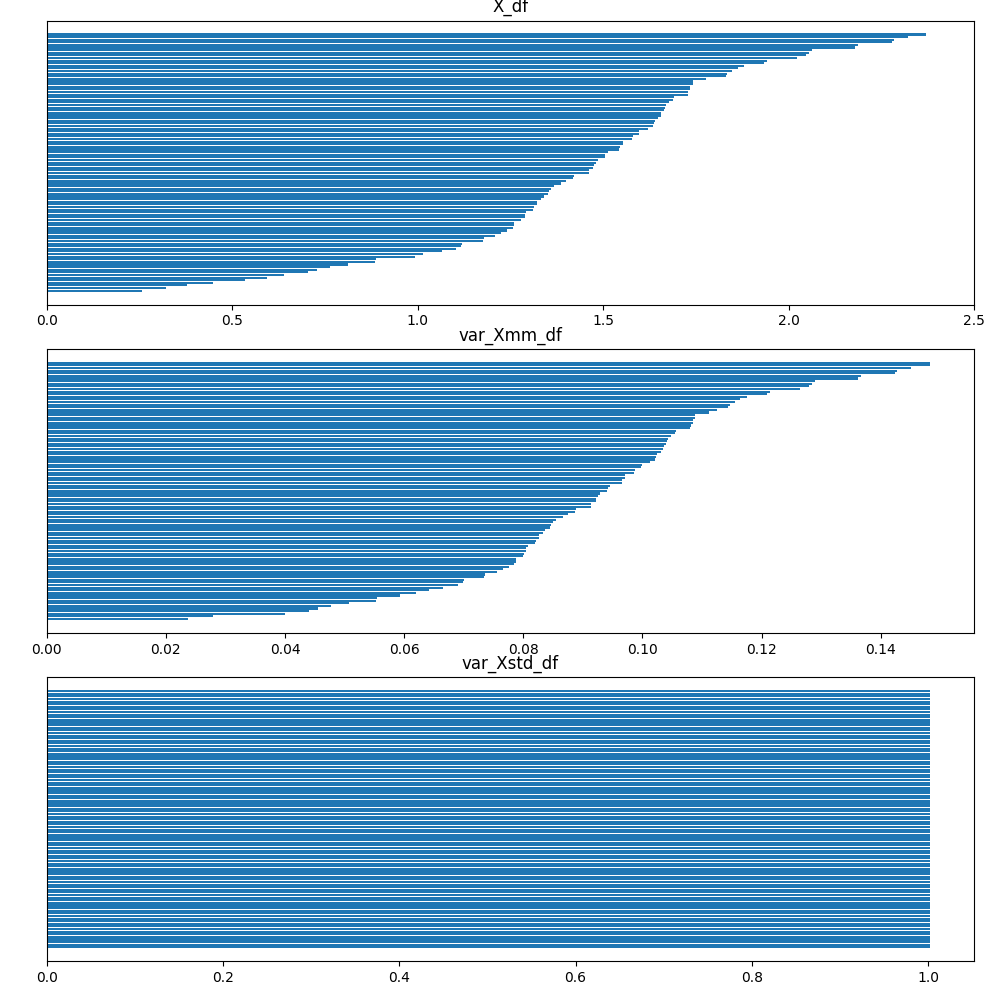

In [7]:
scaler = StandardScaler()
minmax = MinMaxScaler()

Xstd_df = pd.DataFrame(scaler.fit_transform(X_df), columns=X_df.columns)
Xmm_df = pd.DataFrame(minmax.fit_transform(X_df), columns=X_df.columns)

var_X_df = X_df.var()
var_Xmm_df = Xmm_df.var()
var_Xstd_df = Xstd_df.var()


fig, ax = plt.subplots(3, 1, figsize = (10,10))

plt.tight_layout()

ax[0].barh(var_X_df.index, np.sort(var_X_df.values))
ax[0].set_yticks([])
ax[0].set_xticks(np.linspace(0,2.5, 6))
ax[0].set_title('X_df')

ax[1].barh(var_Xmm_df.index, np.sort(var_Xmm_df.values))
ax[1].set_yticks([])
# ax[1].set_xticks(np.linspace(0,2.5, 6))
ax[1].set_title('var_Xmm_df')

ax[2].barh(var_Xstd_df.index, np.sort(var_Xstd_df.values))
ax[2].set_yticks([])
# ax[2].set_xticks(np.linspace(0,2.5, 6))
ax[2].set_title('var_Xstd_df')




plt.show()

# Xmm_df['Punctuality']
# plt.scatter(Xmm_df.index, Xmm_df['Punctuality'])


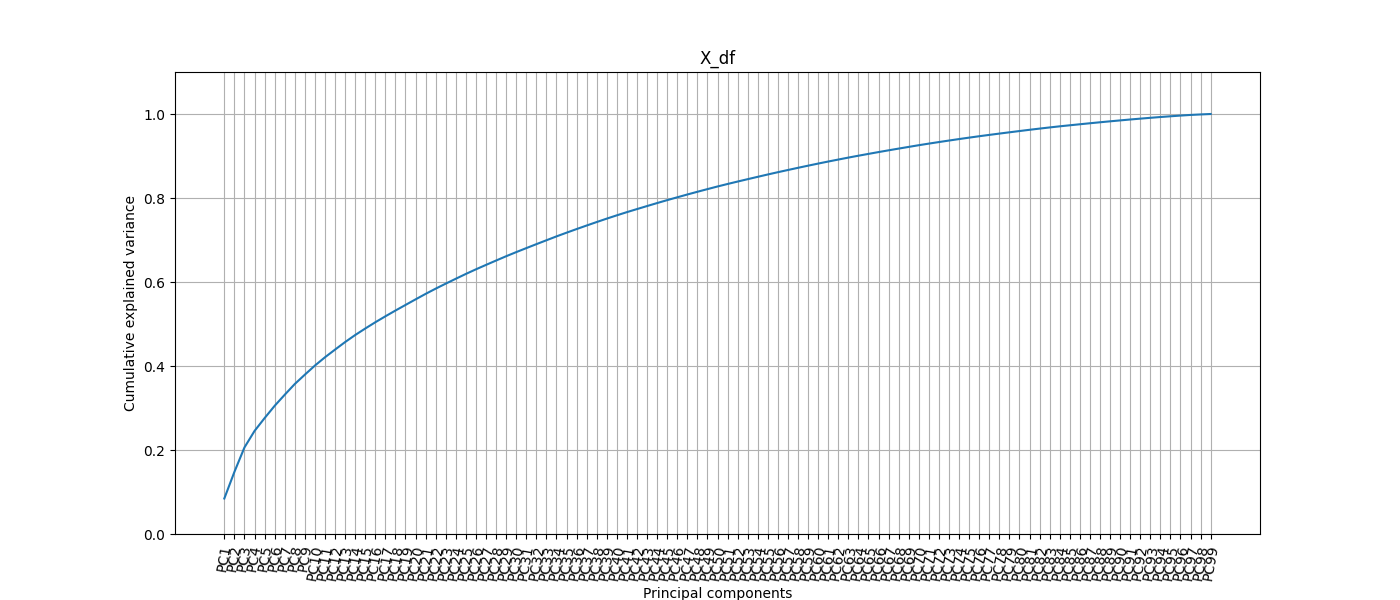

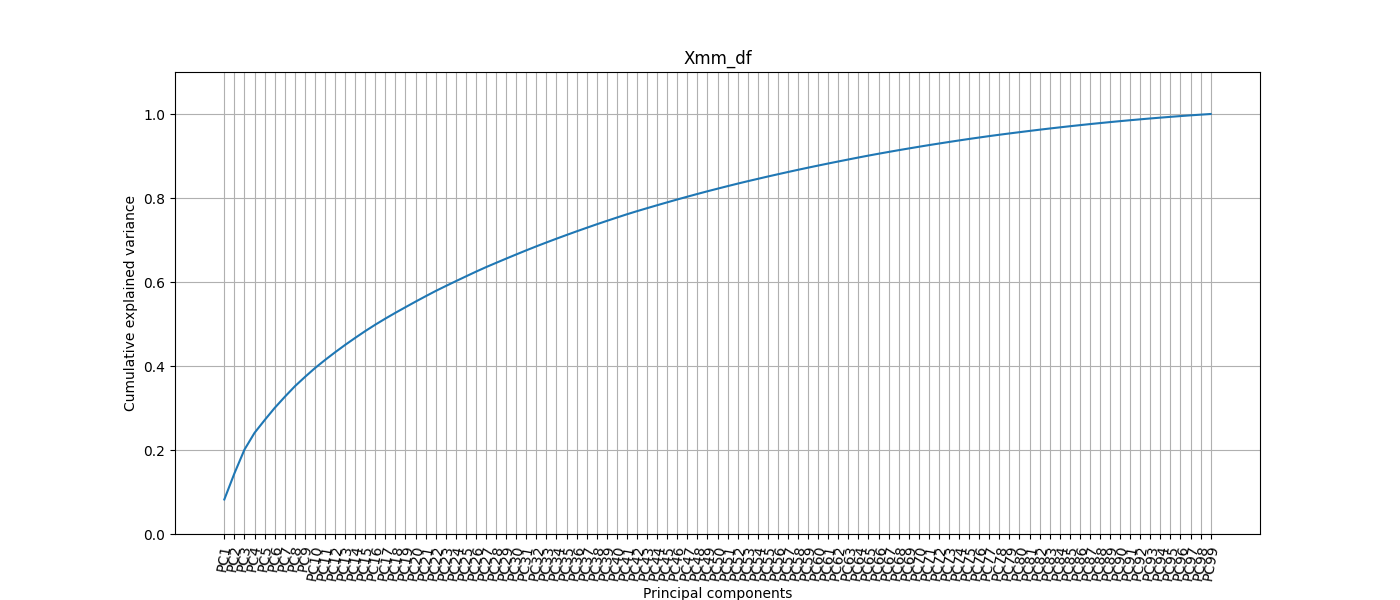

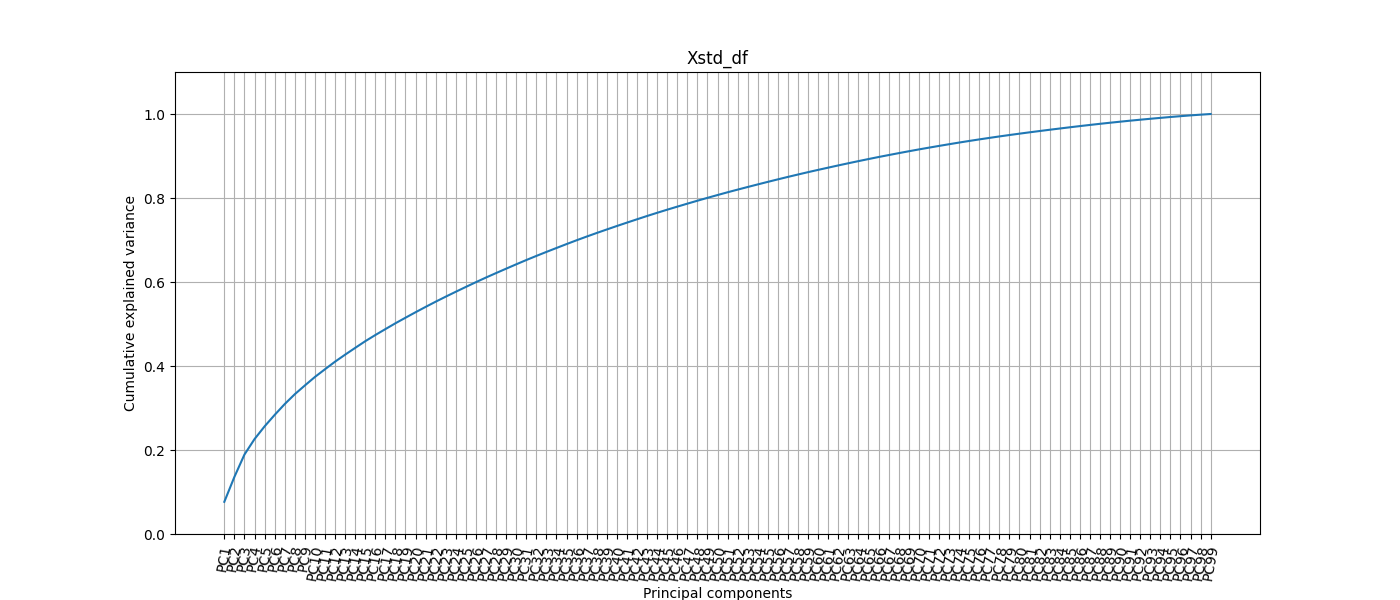

In [8]:
pca_x_df = PCA()
pca_xmm_df = PCA()
pca_xstd_df = PCA()


pca_x_df.fit(X_df.values)
pca_xmm_df.fit(Xmm_df.values)
pca_xstd_df.fit(Xstd_df.values)


plt.figure(figsize = (14,6))
plt.plot(np.cumsum(pca_x_df.explained_variance_ratio_))
plt.title('X_df')
plt.ylim([0, 1.1])
plt.xticks(ticks=np.arange(pca_x_df.n_features_in_), 
           labels=[f'PC{i + 1}' for i in range(pca_x_df.n_features_in_)], rotation = 80)
plt.xlabel('Principal components')
plt.ylabel('Cumulative explained variance')
plt.grid()
plt.show()

plt.figure(figsize = (14,6))
plt.plot(np.cumsum(pca_xmm_df.explained_variance_ratio_))
plt.title('Xmm_df')
plt.ylim([0, 1.1])
plt.xticks(ticks=np.arange(pca_xmm_df.n_features_in_), 
           labels=[f'PC{i + 1}' for i in range(pca_xmm_df.n_features_in_)], rotation = 80)
plt.xlabel('Principal components')
plt.ylabel('Cumulative explained variance')
plt.grid()
plt.show()

plt.figure(figsize = (14,6))
plt.plot(np.cumsum(pca_xstd_df.explained_variance_ratio_))
plt.title('Xstd_df')
plt.ylim([0, 1.1])
plt.xticks(ticks=np.arange(pca_xstd_df.n_features_in_), 
           labels=[f'PC{i + 1}' for i in range(pca_xstd_df.n_features_in_)], rotation = 80)
plt.xlabel('Principal components')
plt.ylabel('Cumulative explained variance')
plt.grid()
plt.show()


## Exercise 3. Dimensionality Reduction and PC Interpretation

In the cells below, do the following operations:
1. For each one of the two dataframes _Xstd_df_, and _Xmm_df_, compute a new PCA for performing a dimensionality reduction with respect to $m$ dimensions. The value of $m$ must be $$m = \min\{m', 5\}\,,$$ where $m'$ is the value required for obtaining $33\%$ of the total variance.
2. For both the cases, visualize all the PCs and give a name/interpretation to them. **Comment and motivate your interpretations**. If possible, **compare the differences among the results obtained** for _Xstd_df_ and _Xmm_df_.
3. Perform the score graph for both the cases (_std_ and _mm_). If $m>3$, plot the score graph with respect to the first 3 PCs. All the **plots must show the names of the PCs on the axes** for better understanding the results.
4. **Optional:** plot more score graphs, coloring the dots with respect to any label in the list _labels_ that you believe can be interesting. **Comment and analyze this optional plots**.

In [27]:
m_xmm = (np.cumsum(pca_x_df.explained_variance_ratio_) < 0.33).sum()
m_std = (np.cumsum(pca_x_df.explained_variance_ratio_) < 0.33).sum()

m_xmm = min([m_xmm, 5])
m_std = min([m_std, 5])

m_xmm, m_std

(5, 5)

Colonna le tipi di domande

In [10]:
set2 = cm.Set2.colors

type_colors = {
    'Personality': set2[0],
    'Health': set2[1],
    'Finance': set2[2],
    'Interests': set2[3],
    'Music': set2[4]
}

these_types_col = []
for t in these_types:
    if t != 'Personality':
        these_types_col += [t]*len(variables_by_type[t])
    else:
        these_types_col += [t]*int(2 * (len(variables_by_type[t]) / 3))  

types_df = pd.DataFrame()
types_df['type'] = these_types_col
types_df['feature'] = these_features
types_df['color'] = types_df['type'].apply(lambda x: type_colors[x])  # <-- TODO!!
types_df

,type,feature,color
0,Personality,Charity,"(0.4, 0.7607843137254902, 0.6470588235294118)"
1,Personality,Hypochondria,"(0.4, 0.7607843137254902, 0.6470588235294118)"
2,Personality,Final judgement,"(0.4, 0.7607843137254902, 0.6470588235294118)"
3,Personality,Funniness,"(0.4, 0.7607843137254902, 0.6470588235294118)"
4,Personality,Eating to survive,"(0.4, 0.7607843137254902, 0.6470588235294118)"
...,...,...,...
94,Music,Rock n roll,"(0.6509803921568628, 0.8470588235294118, 0.329..."
95,Music,Alternative,"(0.6509803921568628, 0.8470588235294118, 0.329..."
96,Music,Latino,"(0.6509803921568628, 0.8470588235294118, 0.329..."
97,Music,"Techno, Trance","(0.6509803921568628, 0.8470588235294118, 0.329..."


## Lavoro con quello minmax

In [11]:
columns = pd.read_csv('columns_hw.csv', header=None)
columns['question'] = columns[0].apply(lambda x: x.split(',')[0])
columns['name'] = columns[0].apply(lambda x: x.split(',')[1])
columns = columns.drop(columns=[0])
columns.loc[columns['name'] == '"Final judgement"']['question']

82    I believe that bad people will suffer one day ...
Name: question, dtype: object

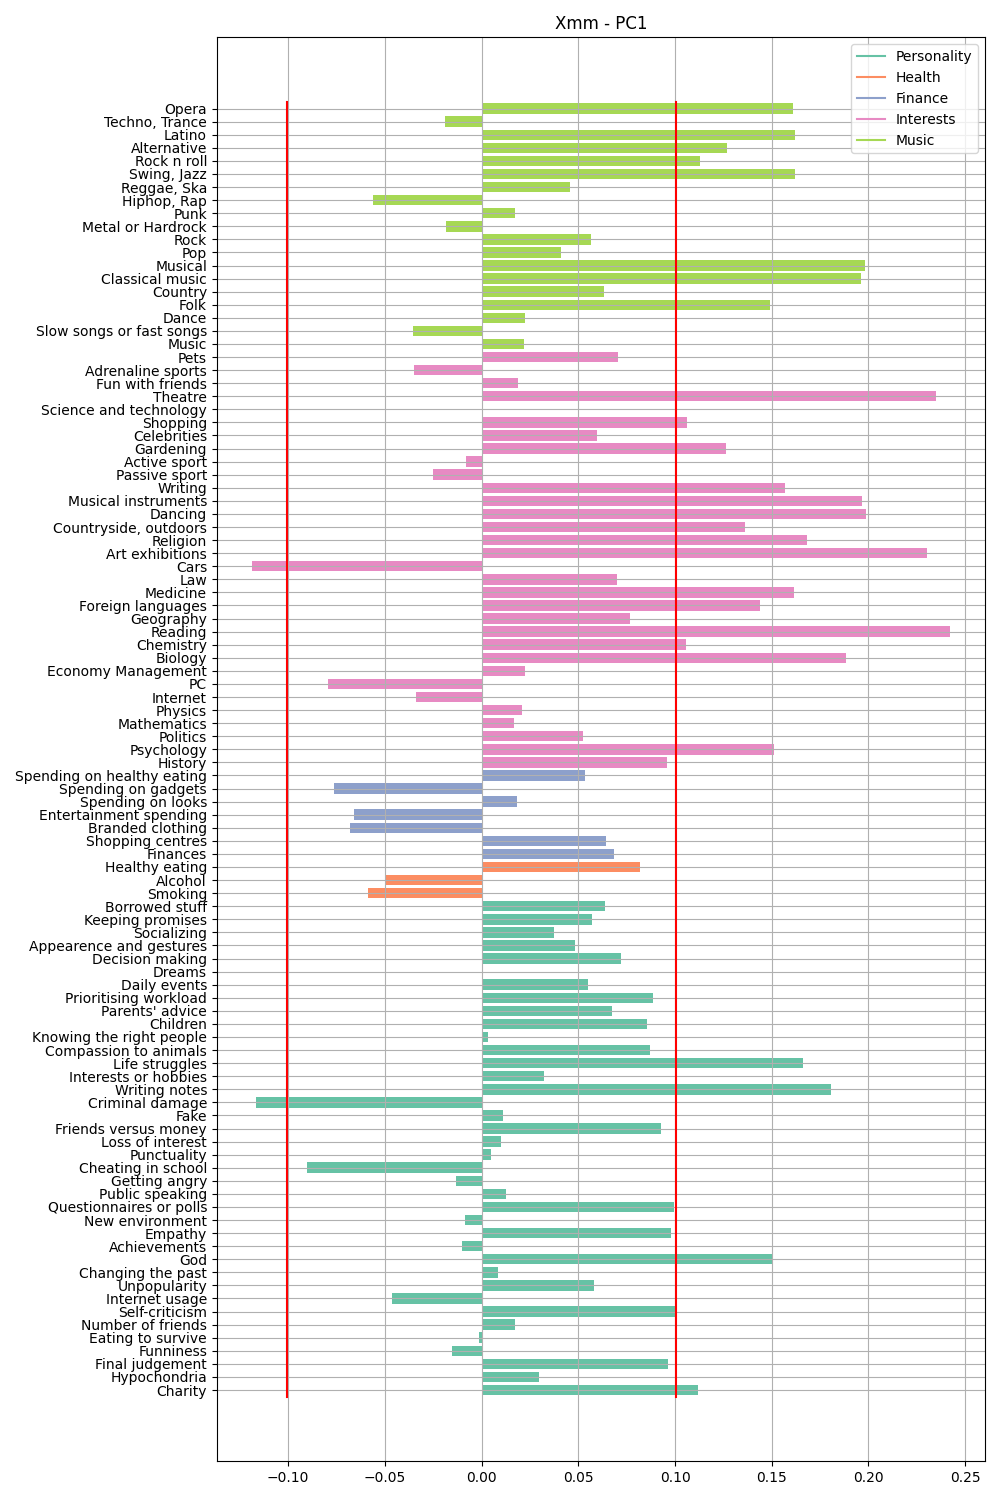


****************** PC1 **********************
HIGH-VALUED POSITIVE COMPONENTS: ['Charity', 'God', 'Writing notes', 'Life struggles', 'Psychology', 'Biology', 'Chemistry', 'Reading', 'Foreign languages', 'Medicine', 'Art exhibitions', 'Religion', 'Countryside, outdoors', 'Dancing', 'Musical instruments', 'Writing', 'Gardening', 'Shopping', 'Theatre', 'Folk', 'Classical music', 'Musical', 'Swing, Jazz', 'Rock n roll', 'Alternative', 'Latino', 'Opera']

HIGH-VALUED NEGATIVE COMPONENTS: ['Criminal damage', 'Cars']
*********************************************



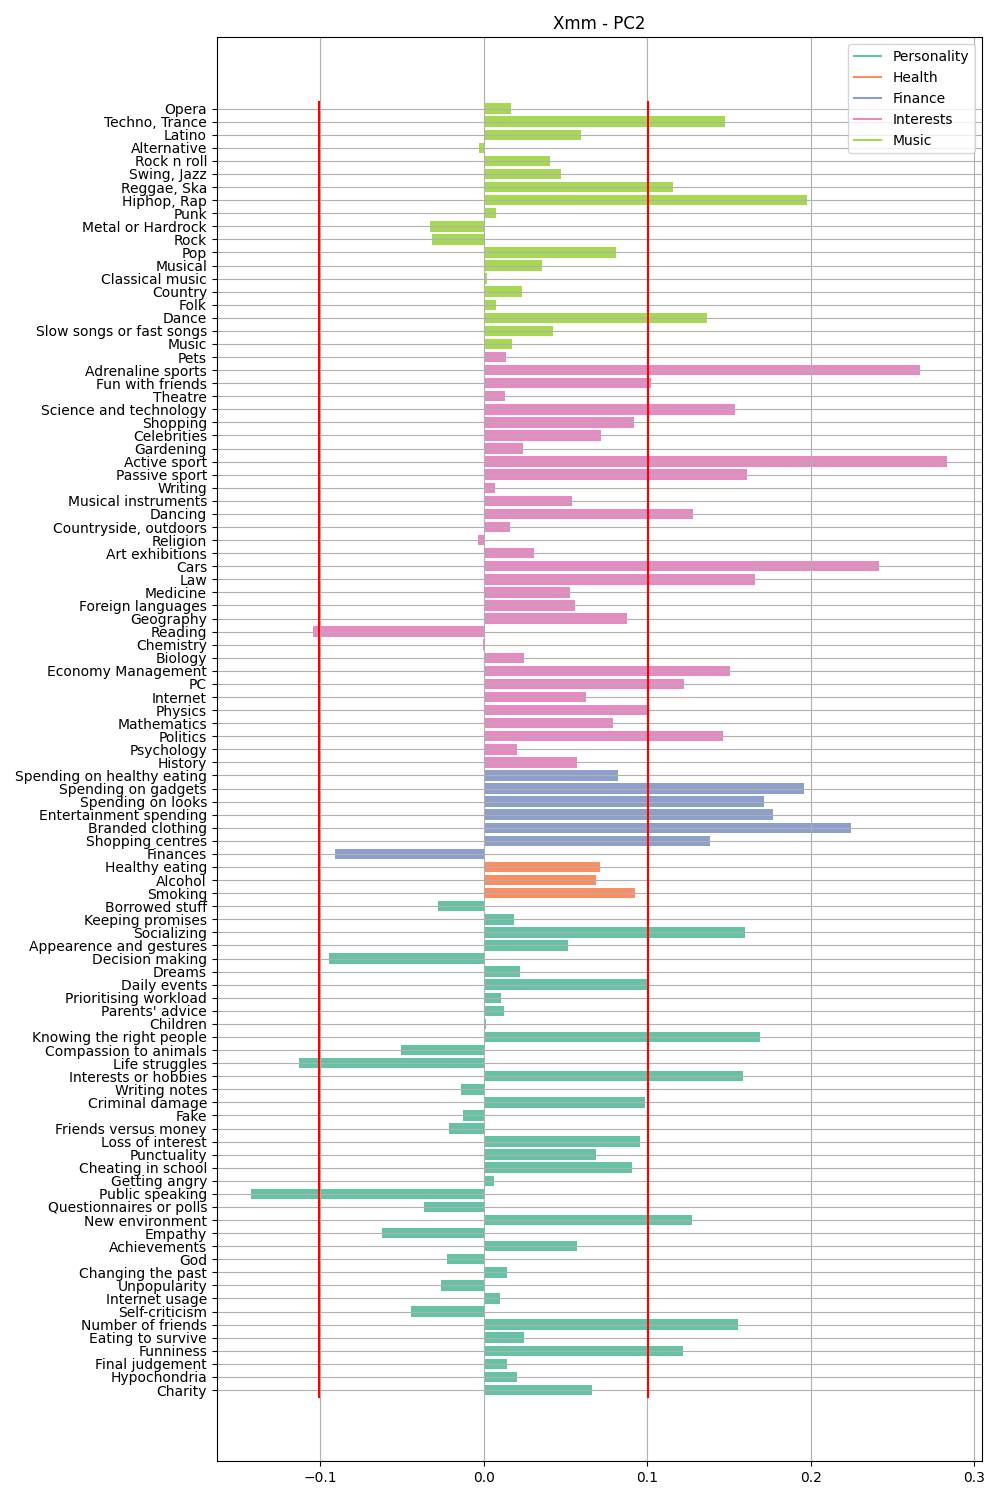


****************** PC2 **********************
HIGH-VALUED POSITIVE COMPONENTS: ['Funniness', 'Number of friends', 'New environment', 'Interests or hobbies', 'Knowing the right people', 'Daily events', 'Socializing', 'Shopping centres', 'Branded clothing', 'Entertainment spending', 'Spending on looks', 'Spending on gadgets', 'Politics', 'PC', 'Economy Management', 'Law', 'Cars', 'Dancing', 'Passive sport', 'Active sport', 'Science and technology', 'Fun with friends', 'Adrenaline sports', 'Dance', 'Hiphop, Rap', 'Reggae, Ska', 'Techno, Trance']

HIGH-VALUED NEGATIVE COMPONENTS: ['Public speaking', 'Life struggles', 'Reading']
*********************************************



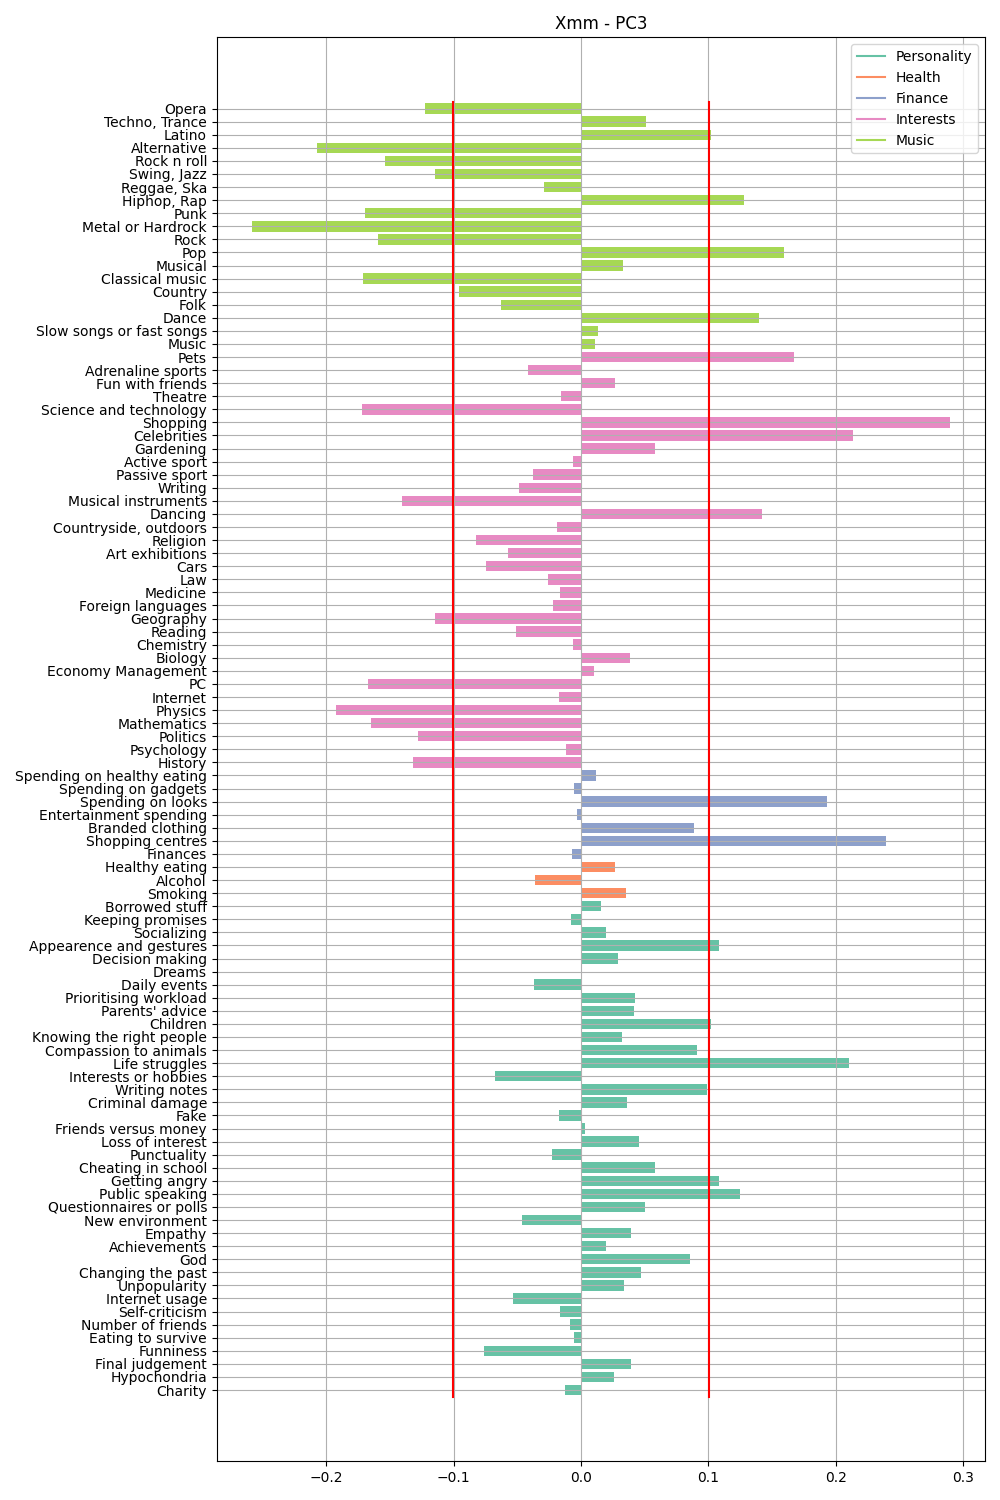


****************** PC3 **********************
HIGH-VALUED POSITIVE COMPONENTS: ['Public speaking', 'Getting angry', 'Life struggles', 'Children', 'Appearence and gestures', 'Shopping centres', 'Spending on looks', 'Dancing', 'Celebrities', 'Shopping', 'Pets', 'Dance', 'Pop', 'Hiphop, Rap', 'Latino']

HIGH-VALUED NEGATIVE COMPONENTS: ['History', 'Politics', 'Mathematics', 'Physics', 'PC', 'Geography', 'Musical instruments', 'Science and technology', 'Classical music', 'Rock', 'Metal or Hardrock', 'Punk', 'Swing, Jazz', 'Rock n roll', 'Alternative', 'Opera']
*********************************************



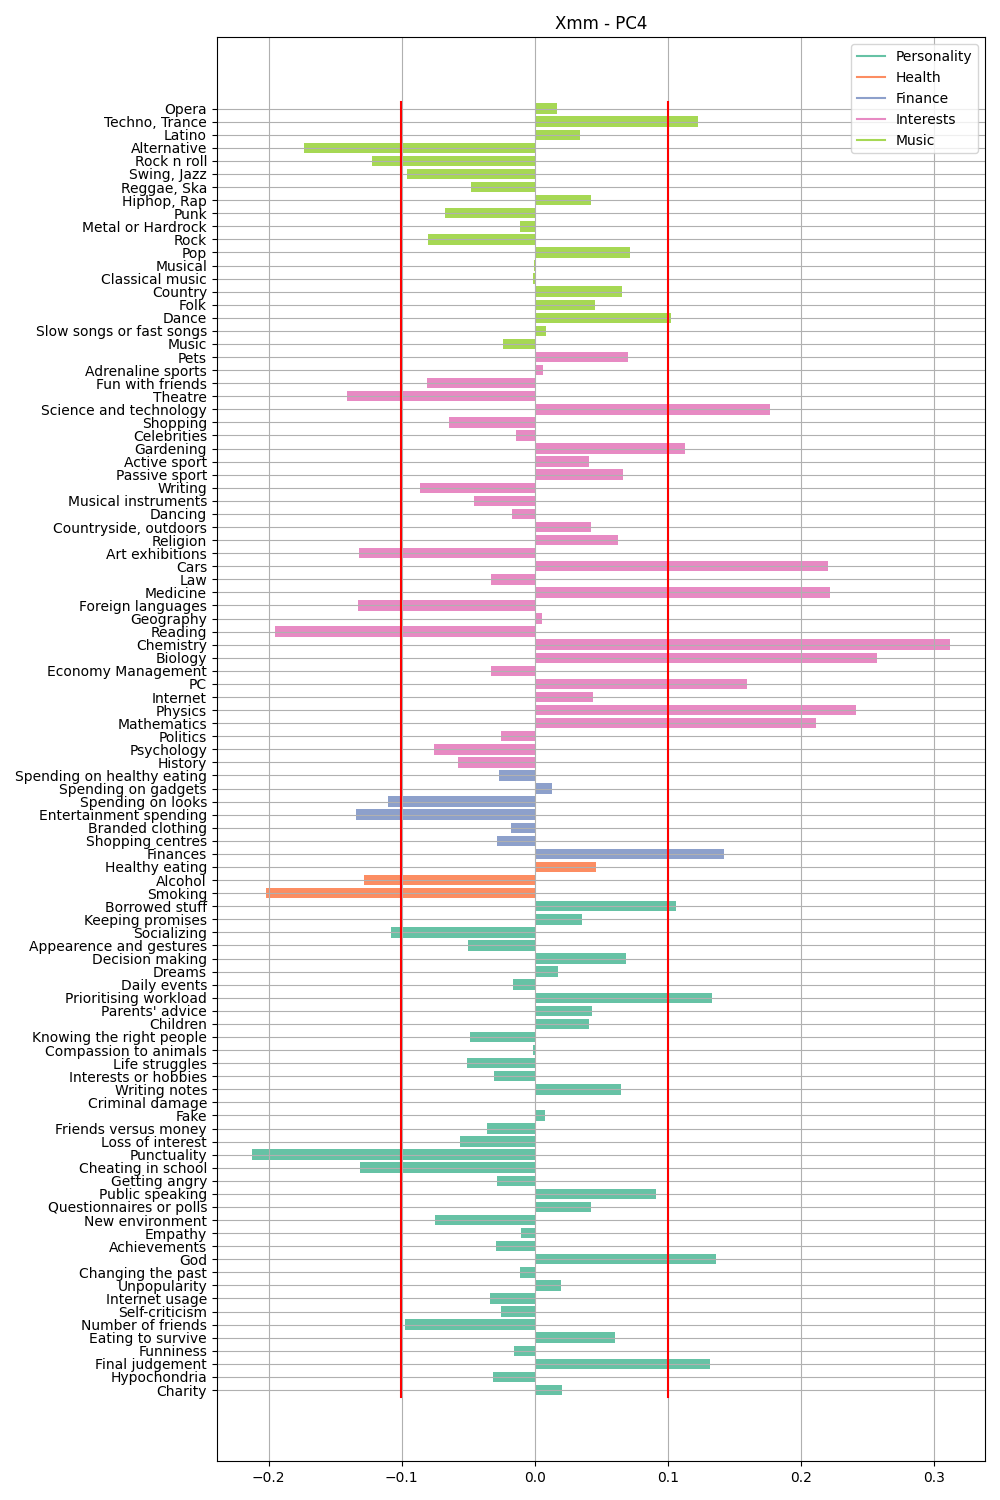


****************** PC4 **********************
HIGH-VALUED POSITIVE COMPONENTS: ['Final judgement', 'God', 'Prioritising workload', 'Borrowed stuff', 'Finances', 'Mathematics', 'Physics', 'PC', 'Biology', 'Chemistry', 'Medicine', 'Cars', 'Gardening', 'Science and technology', 'Dance', 'Techno, Trance']

HIGH-VALUED NEGATIVE COMPONENTS: ['Cheating in school', 'Punctuality', 'Socializing', 'Smoking', 'Alcohol', 'Entertainment spending', 'Spending on looks', 'Reading', 'Foreign languages', 'Art exhibitions', 'Theatre', 'Rock n roll', 'Alternative']
*********************************************



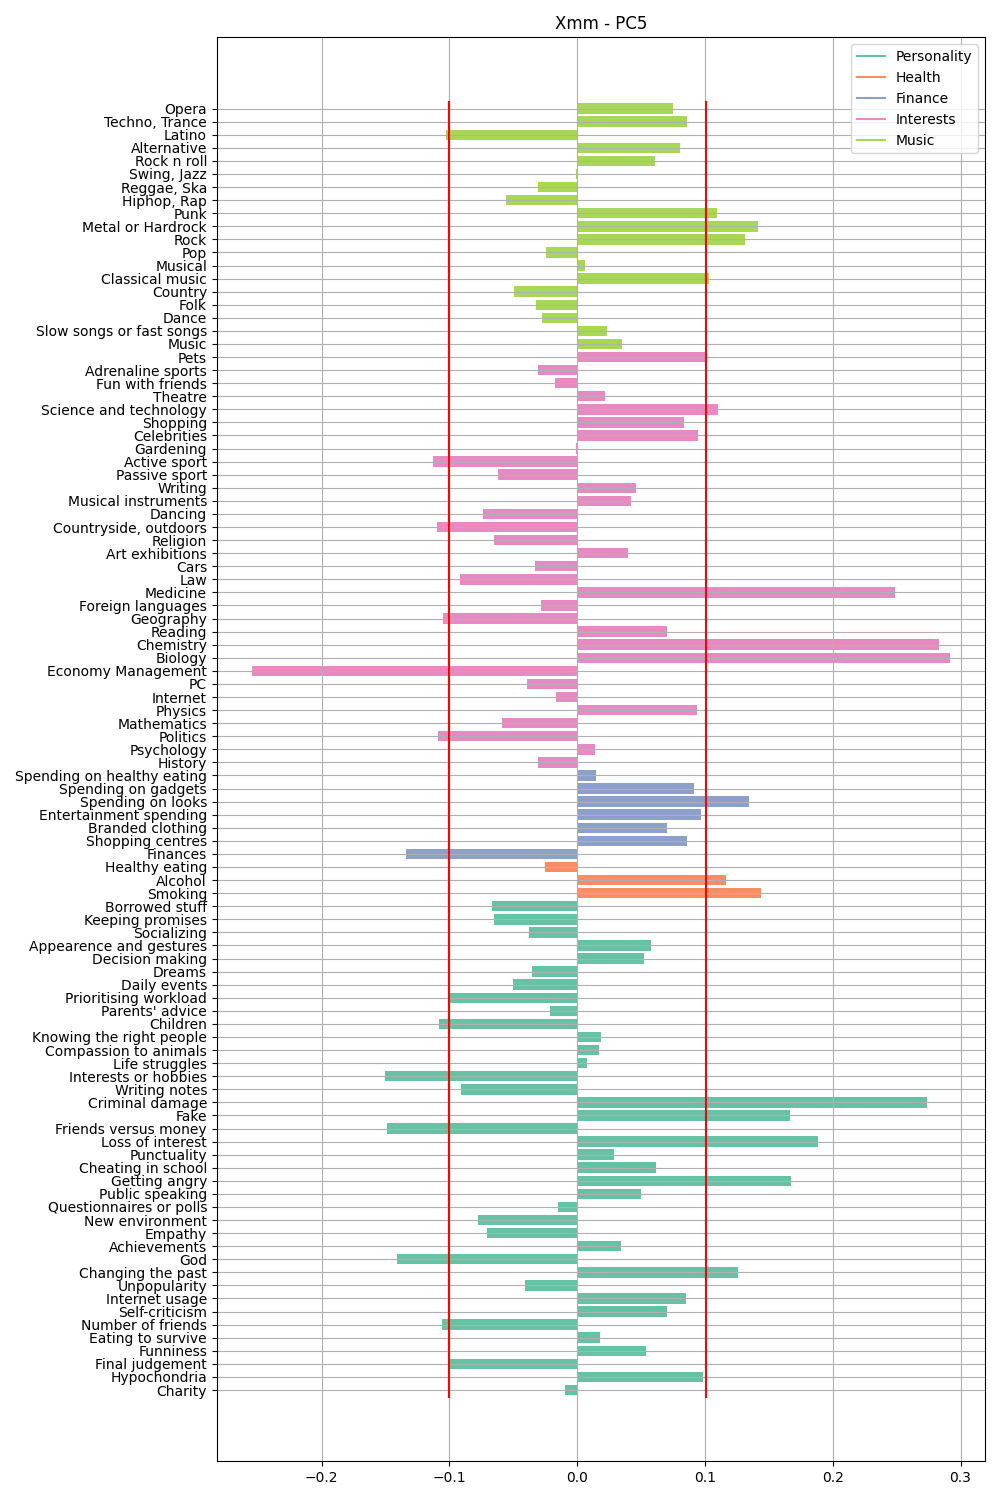


****************** PC5 **********************
HIGH-VALUED POSITIVE COMPONENTS: ['Changing the past', 'Getting angry', 'Loss of interest', 'Fake', 'Criminal damage', 'Smoking', 'Alcohol', 'Spending on looks', 'Biology', 'Chemistry', 'Medicine', 'Science and technology', 'Pets', 'Classical music', 'Rock', 'Metal or Hardrock', 'Punk']

HIGH-VALUED NEGATIVE COMPONENTS: ['Number of friends', 'God', 'Friends versus money', 'Interests or hobbies', 'Children', 'Prioritising workload', 'Finances', 'Politics', 'Economy Management', 'Geography', 'Countryside, outdoors', 'Active sport', 'Latino']
*********************************************



In [33]:
eps = np.sqrt(1 / pca_xmm_df.n_features_in_)

color_types = types_df['color']

type_colors_legend = [Line2D([0], [0], color=type_colors[k]) for k in type_colors.keys()]

for ii in range(m_xmm):
    # MAKE THE BARPLOT WITH SKILL TYPE COLORS
    # ... <-- TODO!!
    plt.figure(figsize=(10, 15))
    plt.barh(np.arange(pca_xmm_df.n_features_in_), pca_xmm_df.components_[ii, :], color=color_types)
    # --- RED LINE DENOTING THE THRESHOLD [-eps, +eps] -----------------
    plt.plot([eps, eps],[-0.5, pca_xmm_df.n_features_in_ - 0.5], 'red')
    plt.plot([-eps, -eps],[-0.5, pca_xmm_df.n_features_in_ - 0.5], 'red')
    # ------------------------------------------------------------------
    plt.yticks(ticks=np.arange(pca_xmm_df.n_features_in_), 
            labels=Xmm_df.columns.to_list())
    plt.title('Xmm - PC'+str(ii+1))
    plt.grid()
    plt.tight_layout()
    plt.legend(type_colors_legend, [k for k in type_colors.keys()])
    
    plt.show()

    # THE SELECTION OF THE SKILLS WITH CONTRIBUTE GREATER THAN THE THRESHOLD
    # ... <-- TODO!!
    ind_great_pos_PCii = np.argwhere(pca_xmm_df.components_[ii, :] >= eps).flatten()
    ind_great_neg_PCii = np.argwhere(pca_xmm_df.components_[ii, :] <= -eps).flatten()
    
    great_pos_PCii = [Xmm_df.columns[i] for i in ind_great_pos_PCii]
    great_neg_PCii = [Xmm_df.columns[i] for i in ind_great_neg_PCii]

    print('')
    print(f'****************** PC{ii+1} **********************')
    print(f'HIGH-VALUED POSITIVE COMPONENTS: {great_pos_PCii}')  # <-- TODO!!
    print('')
    print(f'HIGH-VALUED NEGATIVE COMPONENTS: {great_neg_PCii}')  # <-- TODO!!
    print('*********************************************')
    print('')

### Score graph

In [13]:
# LIST OF THE NAMES ASSIGNED TO THE THREE PCs
pc_names_xmm = ['(-) Materialista vs Cultura (+)', 
           'Estroversione e Materialismo', 
           'Ansia sociale, apparenza',
           'Razionalità, scienza',
           'Trasgressivo']

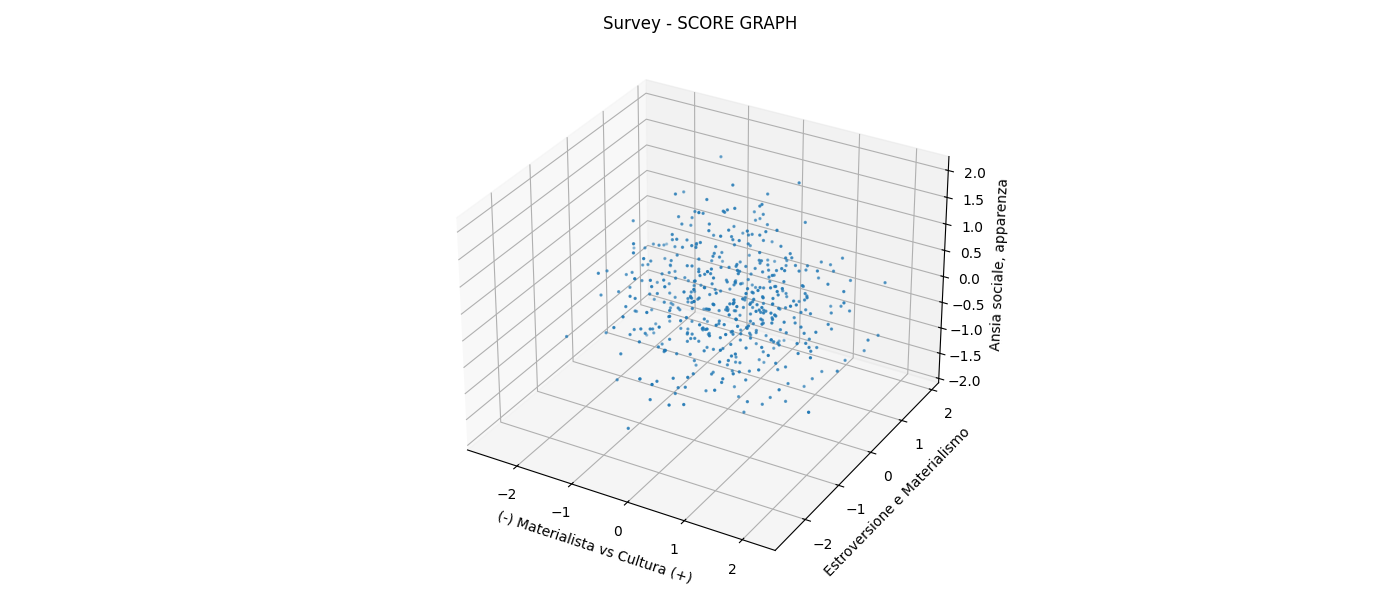

In [14]:
# SAVE THE COLORS OF Set1 AS A LIST OF 3-TUPLES "(red_value, green_value, blue_value)"
set1 = cm.Set1.colors

######### SHOWING THE COLORS OF THE CHOSEN COLORMAP #########
# display(cm.Set1)
#############################################################


# COMPUTE THE DATA TRANSFORMATION INTO THE PC-SPACE
Y_mm = pca_xmm_df.transform(Xmm_df.values)  # <-- TODO!!


# MAKE THE 3D SCORE GRAPH
sg_3d = plt.figure(figsize=(14,6))
ax_sg_3d = sg_3d.add_subplot(111, projection='3d')
ax_sg_3d.scatter(Y_mm[:, 0], Y_mm[:, 1], Y_mm[:, 2], s=2)  # <-- TODO!!
plt.title('Survey - SCORE GRAPH')
plt.tight_layout()
ax_sg_3d.set_xlabel(pc_names_xmm[0])
ax_sg_3d.set_ylabel(pc_names_xmm[1])
ax_sg_3d.set_zlabel(pc_names_xmm[2])
plt.grid()
plt.show()

4. **Optional:** plot more score graphs, coloring the dots with respect to any label in the list _labels_ that you believe can be interesting. **Comment and analyze this optional plots**.

In [15]:
df_label = semi_df.loc[:, labels[:3] + ['Gender']]

arr = np.array(df_label.values[:,:3], dtype=np.float32)

df_label['BMI'] = arr[:,2]/np.square(arr[:,1]/100)
df_label

,Age,Height,Weight,Gender,BMI
139,19.0,168.0,53.0,female,18.778345
393,21.0,176.0,75.0,male,24.212294
541,20.0,175.0,53.0,female,17.306122
1009,21.0,185.0,72.0,male,21.037252
870,25.0,168.0,63.0,female,22.321430
...,...,...,...,...,...
956,20.0,178.0,83.0,male,26.196188
296,23.0,190.0,90.0,male,24.930748
411,18.0,173.0,60.0,female,20.047445
670,23.0,170.0,60.0,female,20.761246


analizzo possibili caratteristiche piuttosto divisive come il genere, l'età e le caratteristiche fisiche
Calcolo il bmi per analizzare peso ed altezza insieme

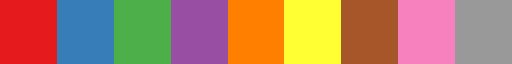

C:\Users\danie\AppData\Local\Temp\ipykernel_14776\1003172383.py:22: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  img = ax_sg_3d.scatter(Y_mm[:, 0], Y_mm[:, 1], Y_mm[:, 2], s=20, c=colors, cmap='magma')  # <-- TODO!!


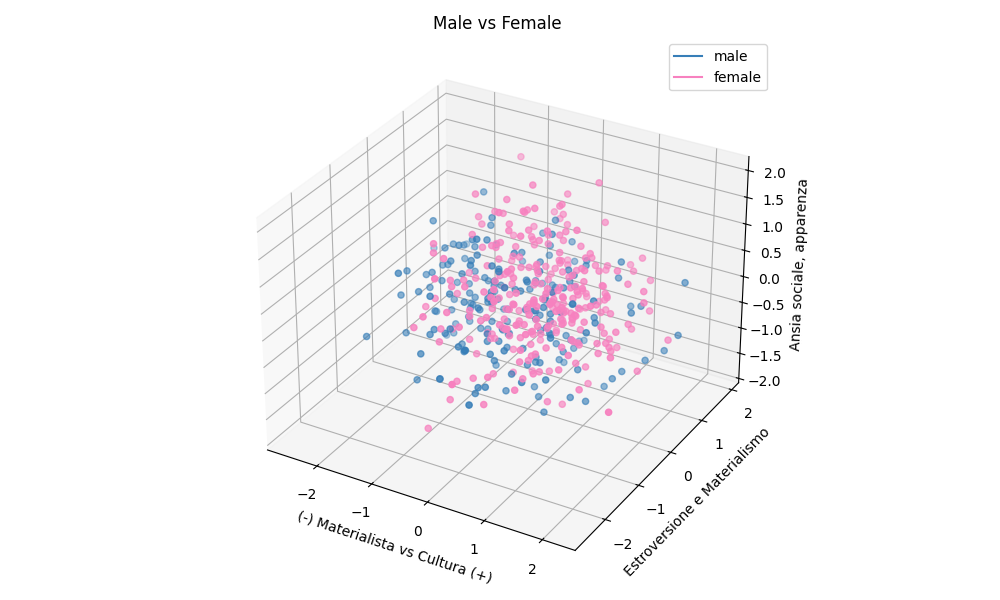

In [16]:
# SAVE THE COLORS OF Set1 AS A LIST OF 3-TUPLES "(red_value, green_value, blue_value)"
set1 = cm.Set1.colors

######### SHOWING THE COLORS OF THE CHOSEN COLORMAP #########
display(cm.Set1)
#############################################################

gender_colors = {'male': set1[1],
                 'female': set1[7]}

gender_colors_legend = [Line2D([0], [0], color=gender_colors[k]) for k in gender_colors.keys()]

colors = semi_df['Gender'].apply(lambda x: gender_colors[x])  # <-- TODO!!


# COMPUTE THE DATA TRANSFORMATION INTO THE PC-SPACE
Y_mm = pca_xmm_df.transform(Xmm_df.values)  # <-- TODO!!

# MAKE THE 3D SCORE GRAPH
sg_3d = plt.figure(figsize=(10,6))
ax_sg_3d = sg_3d.add_subplot(111, projection='3d')
img = ax_sg_3d.scatter(Y_mm[:, 0], Y_mm[:, 1], Y_mm[:, 2], s=20, c=colors, cmap='magma')  # <-- TODO!!
plt.title('Male vs Female ')
plt.tight_layout()
ax_sg_3d.set_xlabel(pc_names_xmm[0])
ax_sg_3d.set_ylabel(pc_names_xmm[1])
ax_sg_3d.set_zlabel(pc_names_xmm[2])
# plt.colorbar(img)
plt.grid()
plt.legend(gender_colors_legend, [k for k in gender_colors.keys()])
plt.show()

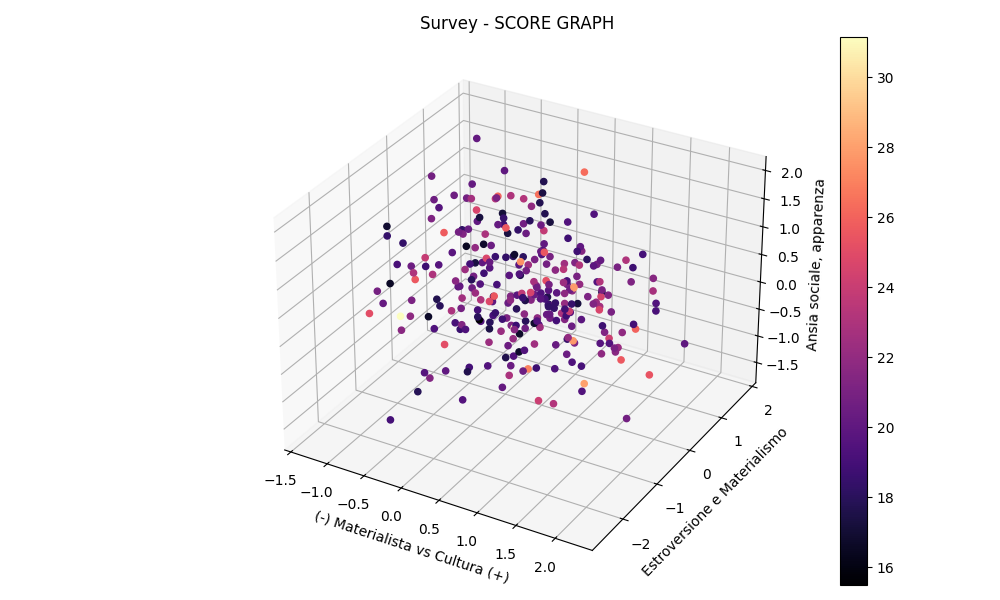

In [17]:
# SAVE THE COLORS OF Set1 AS A LIST OF 3-TUPLES "(red_value, green_value, blue_value)"
set1 = cm.Set1.colors

######### SHOWING THE COLORS OF THE CHOSEN COLORMAP #########
# display(cm.Set1)
#############################################################


# COMPUTE THE DATA TRANSFORMATION INTO THE PC-SPACE
Y_mm = pca_xmm_df.transform(Xmm_df.values)  # <-- TODO!!

Y_bmi = Y_mm[df_label['Gender'] == 'female']


# MAKE THE 3D SCORE GRAPH
sg_3d = plt.figure(figsize=(10,6))
ax_sg_3d = sg_3d.add_subplot(111, projection='3d')
img = ax_sg_3d.scatter(Y_bmi[:, 0], Y_bmi[:, 1], Y_bmi[:, 2], s=20,
                        c=df_label[df_label['Gender'] == 'female']['BMI'], cmap='magma',
                        alpha = 1)  # <-- TODO!!
plt.title('Survey - SCORE GRAPH')
plt.tight_layout()
ax_sg_3d.set_xlabel(pc_names_xmm[0])
ax_sg_3d.set_ylabel(pc_names_xmm[1])
ax_sg_3d.set_zlabel(pc_names_xmm[2])
plt.colorbar(img)
plt.grid()
plt.show()

Sembra che le donne siano molto più ansiose, attente alle apparenze e meno materialiste
Gli uomino tengono meno a come appaiono e sono più estroversi

## Lavoro con quello std

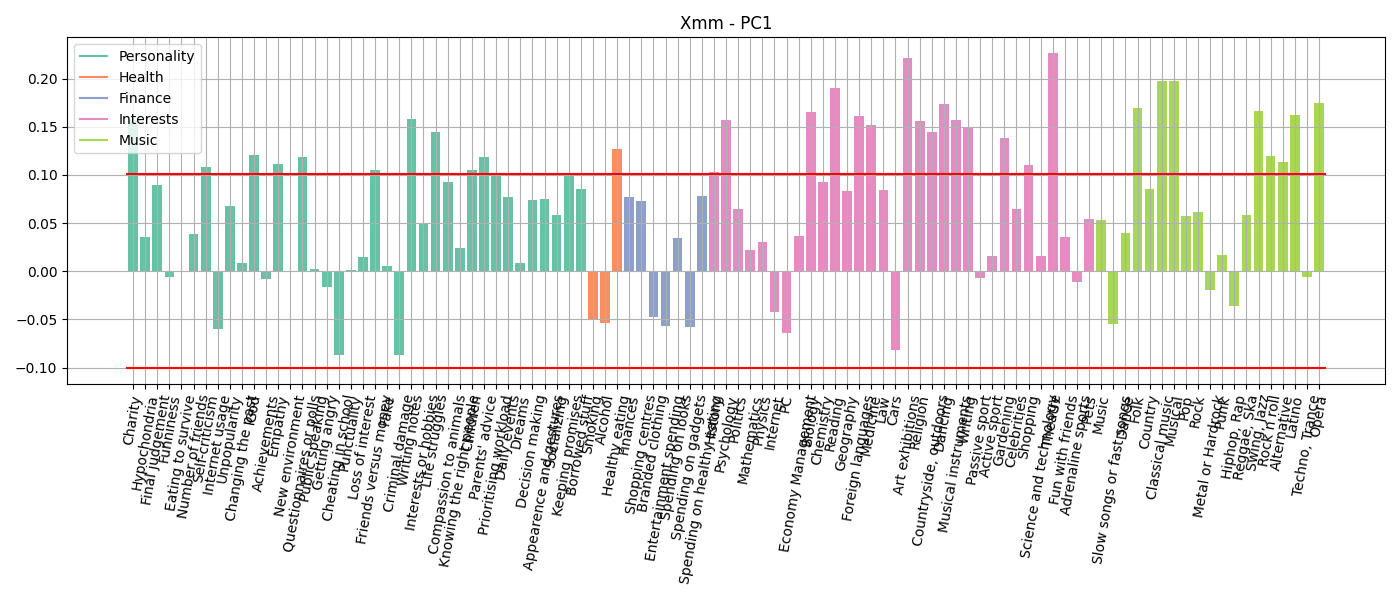


****************** PC1 **********************
HIGH-VALUED POSITIVE COMPONENTS: ['Charity', 'Self-criticism', 'God', 'Empathy', 'Questionnaires or polls', 'Friends versus money', 'Writing notes', 'Life struggles', 'Children', "Parents' advice", 'Healthy eating', 'History', 'Psychology', 'Biology', 'Reading', 'Foreign languages', 'Medicine', 'Art exhibitions', 'Religion', 'Countryside, outdoors', 'Dancing', 'Musical instruments', 'Writing', 'Gardening', 'Shopping', 'Theatre', 'Folk', 'Classical music', 'Musical', 'Swing, Jazz', 'Rock n roll', 'Alternative', 'Latino', 'Opera']

HIGH-VALUED NEGATIVE COMPONENTS: []
*********************************************



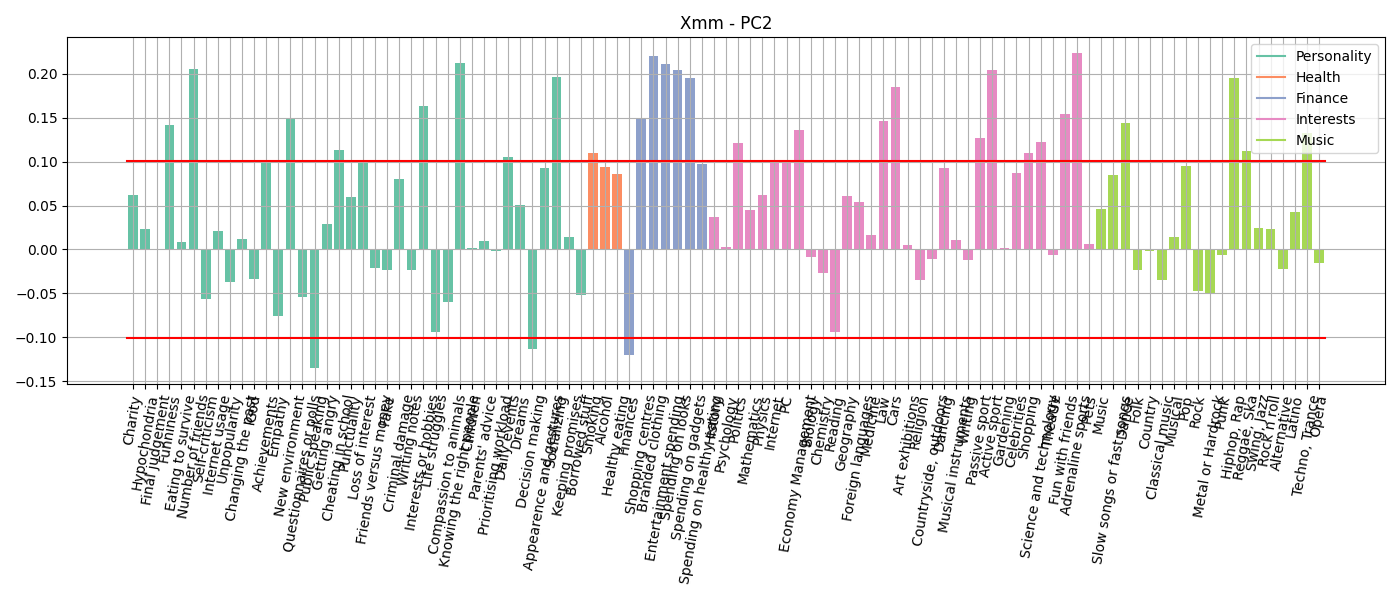


****************** PC2 **********************
HIGH-VALUED POSITIVE COMPONENTS: ['Funniness', 'Number of friends', 'Achievements', 'New environment', 'Cheating in school', 'Interests or hobbies', 'Knowing the right people', 'Daily events', 'Socializing', 'Smoking', 'Shopping centres', 'Branded clothing', 'Entertainment spending', 'Spending on looks', 'Spending on gadgets', 'Politics', 'PC', 'Economy Management', 'Law', 'Cars', 'Passive sport', 'Active sport', 'Shopping', 'Science and technology', 'Fun with friends', 'Adrenaline sports', 'Dance', 'Hiphop, Rap', 'Reggae, Ska', 'Techno, Trance']

HIGH-VALUED NEGATIVE COMPONENTS: ['Public speaking', 'Decision making', 'Finances']
*********************************************



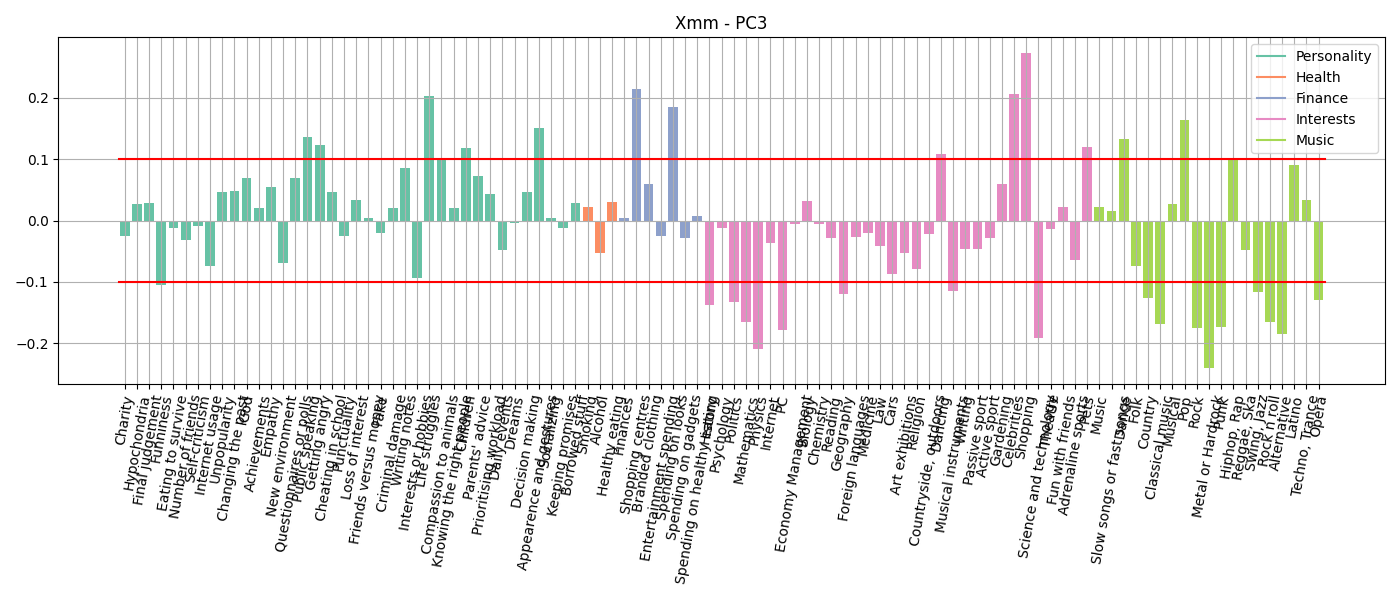


****************** PC3 **********************
HIGH-VALUED POSITIVE COMPONENTS: ['Public speaking', 'Getting angry', 'Life struggles', 'Compassion to animals', 'Children', 'Appearence and gestures', 'Shopping centres', 'Spending on looks', 'Dancing', 'Celebrities', 'Shopping', 'Pets', 'Dance', 'Pop', 'Hiphop, Rap']

HIGH-VALUED NEGATIVE COMPONENTS: ['Funniness', 'History', 'Politics', 'Mathematics', 'Physics', 'PC', 'Geography', 'Musical instruments', 'Science and technology', 'Country', 'Classical music', 'Rock', 'Metal or Hardrock', 'Punk', 'Swing, Jazz', 'Rock n roll', 'Alternative', 'Opera']
*********************************************



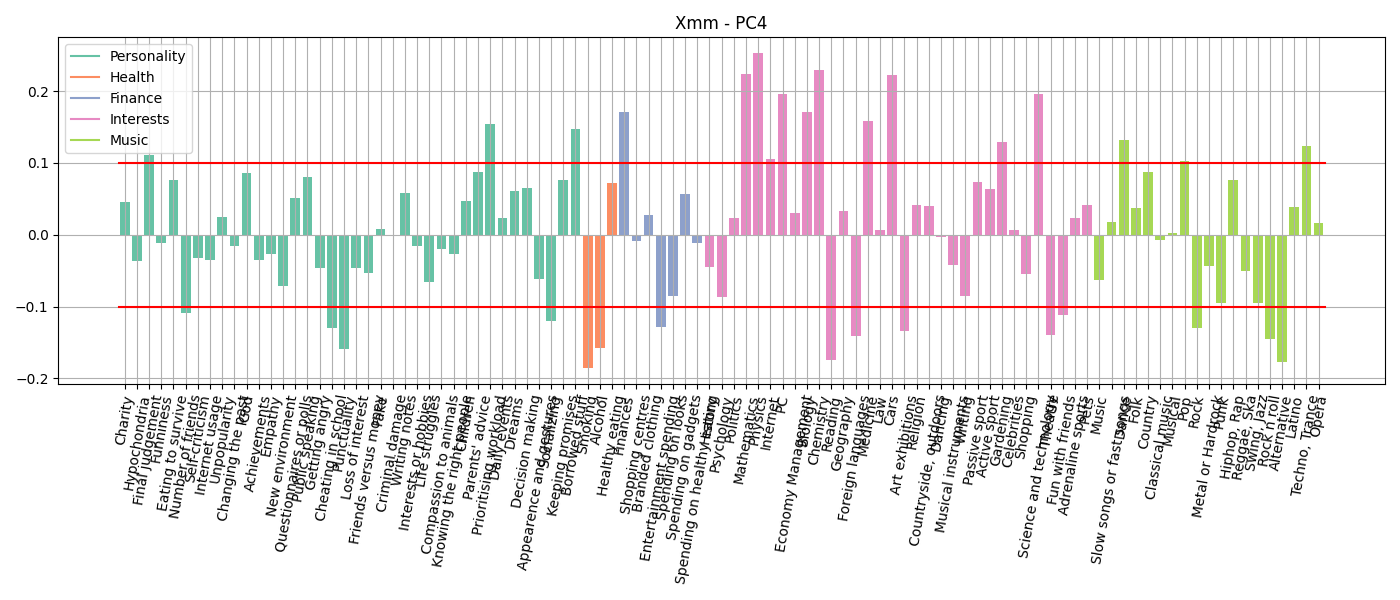


****************** PC4 **********************
HIGH-VALUED POSITIVE COMPONENTS: ['Final judgement', 'Prioritising workload', 'Borrowed stuff', 'Finances', 'Mathematics', 'Physics', 'Internet', 'PC', 'Biology', 'Chemistry', 'Medicine', 'Cars', 'Gardening', 'Science and technology', 'Dance', 'Pop', 'Techno, Trance']

HIGH-VALUED NEGATIVE COMPONENTS: ['Number of friends', 'Cheating in school', 'Punctuality', 'Socializing', 'Smoking', 'Alcohol', 'Entertainment spending', 'Reading', 'Foreign languages', 'Art exhibitions', 'Theatre', 'Fun with friends', 'Rock', 'Rock n roll', 'Alternative']
*********************************************



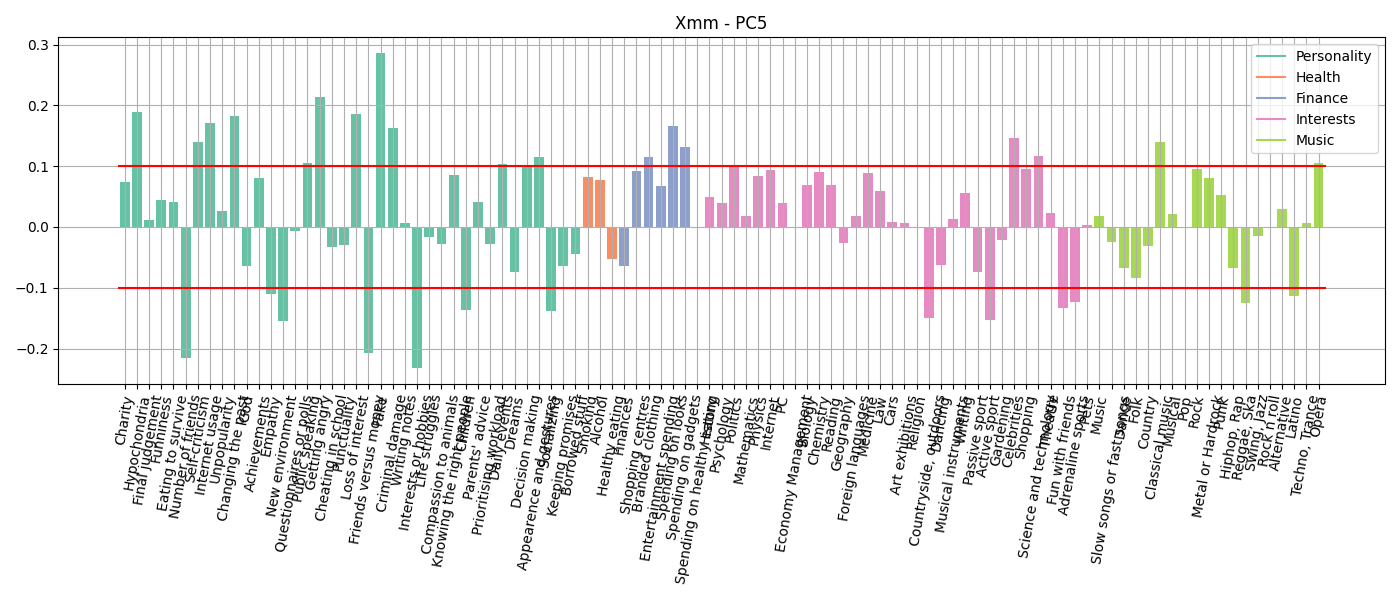


****************** PC5 **********************
HIGH-VALUED POSITIVE COMPONENTS: ['Hypochondria', 'Self-criticism', 'Internet usage', 'Changing the past', 'Public speaking', 'Getting angry', 'Loss of interest', 'Fake', 'Criminal damage', 'Daily events', 'Decision making', 'Appearence and gestures', 'Branded clothing', 'Spending on looks', 'Spending on gadgets', 'Politics', 'Celebrities', 'Science and technology', 'Classical music', 'Opera']

HIGH-VALUED NEGATIVE COMPONENTS: ['Number of friends', 'Empathy', 'New environment', 'Friends versus money', 'Interests or hobbies', 'Children', 'Socializing', 'Countryside, outdoors', 'Active sport', 'Fun with friends', 'Adrenaline sports', 'Reggae, Ska', 'Latino']
*********************************************



In [18]:
eps = np.sqrt(1 / pca_xstd_df.n_features_in_)

color_types = types_df['color']

type_colors_legend = [Line2D([0], [0], color=type_colors[k]) for k in type_colors.keys()]

for ii in range(m_xmm):
    # MAKE THE BARPLOT WITH SKILL TYPE COLORS
    # ... <-- TODO!!
    plt.figure(figsize=(14, 6))
    plt.bar(np.arange(pca_xstd_df.n_features_in_), pca_xstd_df.components_[ii, :], color=color_types)
    # --- RED LINE DENOTING THE THRESHOLD [-eps, +eps] -----------------
    plt.plot([-0.5, pca_xstd_df.n_features_in_ - 0.5], [eps, eps], 'red')
    plt.plot([-0.5, pca_xstd_df.n_features_in_ - 0.5], [-eps, -eps], 'red')
    # ------------------------------------------------------------------
    plt.xticks(ticks=np.arange(pca_xstd_df.n_features_in_), 
            labels=Xstd_df.columns.to_list(),
            rotation=80)
    plt.title('Xmm - PC'+str(ii+1))
    plt.grid()
    plt.tight_layout()
    plt.legend(type_colors_legend, [k for k in type_colors.keys()])

    plt.show()

    # THE SELECTION OF THE SKILLS WITH CONTRIBUTE GREATER THAN THE THRESHOLD
    # ... <-- TODO!!
    ind_great_pos_PCii = np.argwhere(pca_xstd_df.components_[ii, :] >= eps).flatten()
    ind_great_neg_PCii = np.argwhere(pca_xstd_df.components_[ii, :] <= -eps).flatten()
    
    great_pos_PCii = [Xstd_df.columns[i] for i in ind_great_pos_PCii]
    great_neg_PCii = [Xstd_df.columns[i] for i in ind_great_neg_PCii]

    print('')
    print(f'****************** PC{ii+1} **********************')
    print(f'HIGH-VALUED POSITIVE COMPONENTS: {great_pos_PCii}')  # <-- TODO!!
    print('')
    print(f'HIGH-VALUED NEGATIVE COMPONENTS: {great_neg_PCii}')  # <-- TODO!!
    print('*********************************************')
    print('')

In [19]:
pc_names_std = [
    '(-) Materialista vs Cultura (+)',
    'Socialità e Spensieratezza',
    'Rap life model',
    'Razionalità, scienza',
    'Introspettivo, apparenza'
]

### Score graph

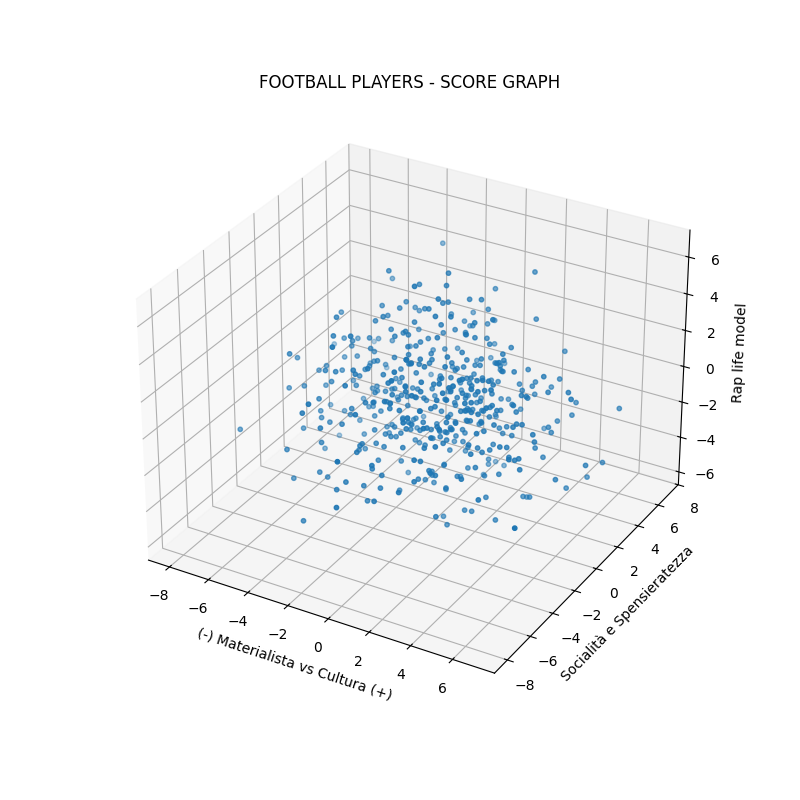

In [20]:
# SAVE THE COLORS OF Set1 AS A LIST OF 3-TUPLES "(red_value, green_value, blue_value)"
set1 = cm.Set1.colors

######### SHOWING THE COLORS OF THE CHOSEN COLORMAP #########
# display(cm.Set1)
#############################################################


# COMPUTE THE DATA TRANSFORMATION INTO THE PC-SPACE
Y_std = pca_xstd_df.transform(Xstd_df.values)  # <-- TODO!!


# MAKE THE 3D SCORE GRAPH
sg_3d = plt.figure(figsize=(8, 8))
ax_sg_3d = sg_3d.add_subplot(111, projection='3d')
ax_sg_3d.scatter(Y_std[:, 0], Y_std[:, 1], Y_std[:, 2], s=10)  # <-- TODO!!
plt.title('FOOTBALL PLAYERS - SCORE GRAPH')
ax_sg_3d.set_xlabel(pc_names_std[0])
ax_sg_3d.set_ylabel(pc_names_std[1])
ax_sg_3d.set_zlabel(pc_names_std[2])
plt.grid()
plt.show()

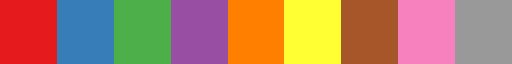

C:\Users\danie\AppData\Local\Temp\ipykernel_14776\1539389254.py:22: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  img = ax_sg_3d.scatter(Y_std[:, 0], Y_std[:, 1], Y_std[:, 2], s=20, c=colors, cmap='magma')  # <-- TODO!!


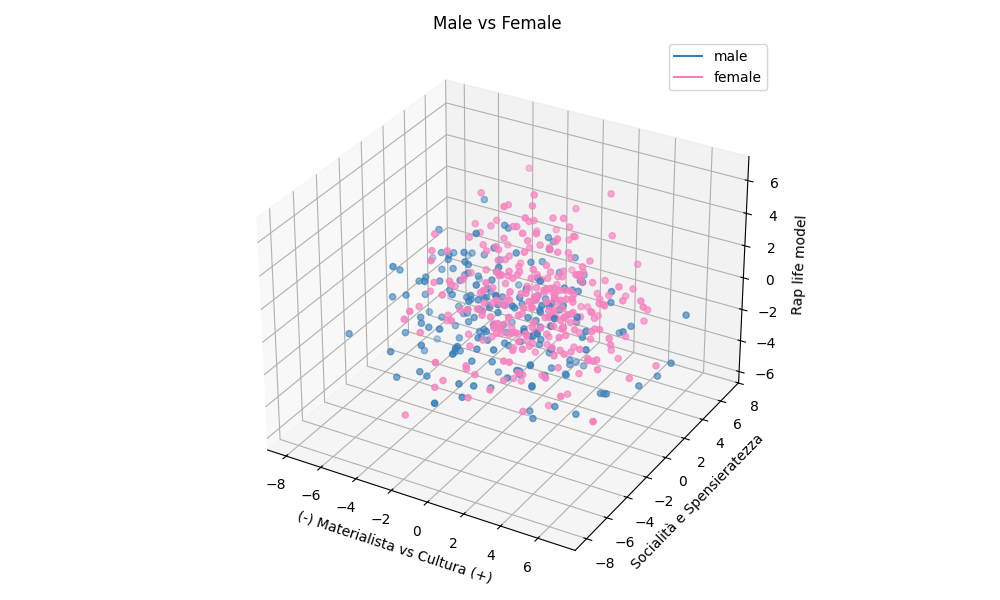

In [21]:
# SAVE THE COLORS OF Set1 AS A LIST OF 3-TUPLES "(red_value, green_value, blue_value)"
set1 = cm.Set1.colors

######### SHOWING THE COLORS OF THE CHOSEN COLORMAP #########
display(cm.Set1)
#############################################################

gender_colors = {'male': set1[1],
                 'female': set1[7]}

gender_colors_legend = [Line2D([0], [0], color=gender_colors[k]) for k in gender_colors.keys()]

colors = semi_df['Gender'].apply(lambda x: gender_colors[x])


# COMPUTE THE DATA TRANSFORMATION INTO THE PC-SPACE
Y_std = pca_xstd_df.transform(Xstd_df.values)  # <-- TODO!!

# MAKE THE 3D SCORE GRAPH
sg_3d = plt.figure(figsize=(10,6))
ax_sg_3d = sg_3d.add_subplot(111, projection='3d')
img = ax_sg_3d.scatter(Y_std[:, 0], Y_std[:, 1], Y_std[:, 2], s=20, c=colors, cmap='magma')  # <-- TODO!!
plt.title('Male vs Female ')
plt.tight_layout()
ax_sg_3d.set_xlabel(pc_names_std[0])
ax_sg_3d.set_ylabel(pc_names_std[1])
ax_sg_3d.set_zlabel(pc_names_std[2])
# plt.colorbar(img)
plt.grid()
plt.legend(gender_colors_legend, [k for k in gender_colors.keys()])
plt.show()

## Exercise 4. $k$-Means

In the cells below, do the following operations:
1. For each one of the two datasets (_std_ and _mm_), run the $k$-Means for clustering the data. In particular, **use the silohuette score for identify the best value for $k\in\{3, \ldots, 10\}$**.
2. Plot the score graphs of exercise 3.3, adding the centroids of the cluster.
3. Observing the centroids coordinates in the PC space, **give a name/interpretation to them**, exploiting the names you assigned to the PCs. **Comment and motivate your interpretations**.

## minmax

In [22]:
random_state = 20241130

# INITIALIZE SOME LISTS TO STORE THE TEMPORARY RESULTS AND, THEN, MAKE COMPARISONS
km_list = []
silcoeff_list = []
k_list = list(range(3, 11))

# START THE FOR-CYCLE TO RUN THE k-MEANS AND MEASURING THE SILHOUETTE COEFFICIENT
for i in range(len(k_list)):
    print(f'****************** START k-MEANS WITH k={k_list[i]} ******************')
    print('Computing...')
    km_list.append(KMeans(k_list[i]))  # <-- TODO!!
    km = km_list[i]
    # attenzione il fit va fatto sui dati trasformati con il pca
    # ... fit the k-means object...  # <-- TODO!!
    km.fit(Y_mm)
    silcoeff_list.append(silhouette_score(Y_mm, km.predict(Y_mm)))  # <-- TODO!!
    print(f'****************** END k-MEANS WITH k={k_list[i]} ******************')
    print('')

# FIND THE BEST VALUE OF k AND THE BEST KMeans OBJECT
i_best = np.argmax(silcoeff_list)  # <-- TODO!!
k = k_list[i_best]
km = km_list[i_best]

# VISUALIZE THE RESULT
print('')
print('')
print('****************** RESULTS OF THE SEARCH... ******************')
print(f'BEST SILHOUETTE SCORE: {np.max(silcoeff_list)} --> k = {k}')  # <-- TODO!!
print('**************************************************************')

****************** START k-MEANS WITH k=3 ******************
Computing...
****************** END k-MEANS WITH k=3 ******************

****************** START k-MEANS WITH k=4 ******************
Computing...
****************** END k-MEANS WITH k=4 ******************

****************** START k-MEANS WITH k=5 ******************
Computing...
****************** END k-MEANS WITH k=5 ******************

****************** START k-MEANS WITH k=6 ******************
Computing...
****************** END k-MEANS WITH k=6 ******************

****************** START k-MEANS WITH k=7 ******************
Computing...
****************** END k-MEANS WITH k=7 ******************

****************** START k-MEANS WITH k=8 ******************
Computing...
****************** END k-MEANS WITH k=8 ******************

****************** START k-MEANS WITH k=9 ******************
Computing...
****************** END k-MEANS WITH k=9 ******************

****************** START k-MEANS WITH k=10 ******************


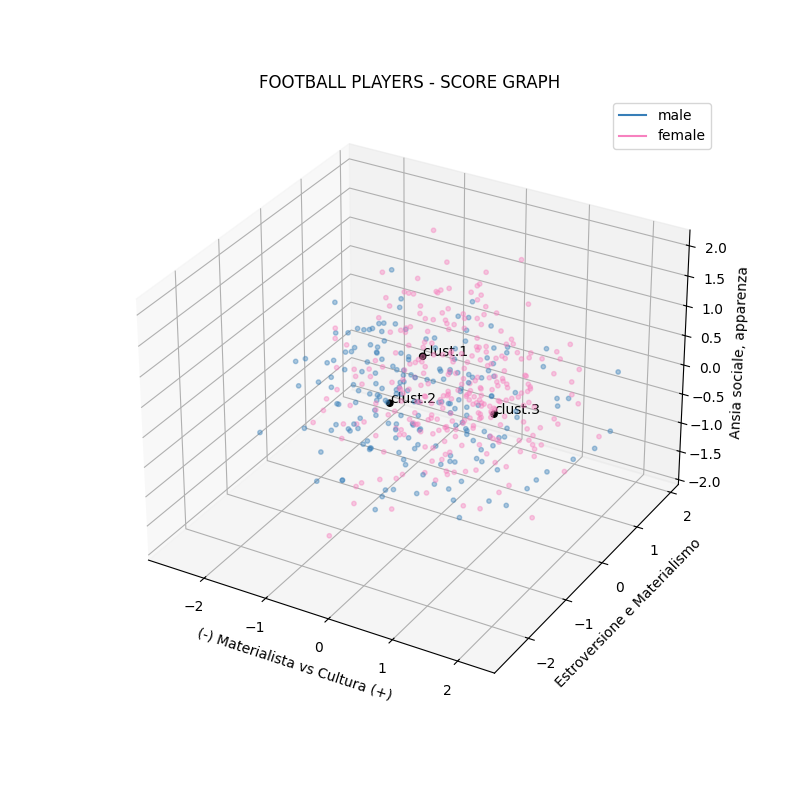

In [23]:
sg_3d = plt.figure(figsize=(8, 8))
ax_sg_3d = sg_3d.add_subplot(111, projection='3d')

gender_colors = {'male': set1[1],
                 'female': set1[7]}

gender_colors_legend = [Line2D([0], [0], color=gender_colors[k]) for k in gender_colors.keys()]

colors = semi_df['Gender'].apply(lambda x: gender_colors[x])

for kk in range(k):
    ax_sg_3d.text(km.cluster_centers_[kk, 0], km.cluster_centers_[kk, 1], km.cluster_centers_[kk, 2], f'clust.{kk + 1}')

ax_sg_3d.scatter(Y_mm[:, 0], Y_mm[:, 1], Y_mm[:, 2], c=colors , s=10, alpha = 0.4)  # <-- TODO!!
ax_sg_3d.scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1], km.cluster_centers_[:, 2], color='black', alpha=1)
plt.title('FOOTBALL PLAYERS - SCORE GRAPH')
ax_sg_3d.set_xlabel(pc_names_xmm[0])
ax_sg_3d.set_ylabel(pc_names_xmm[1])
ax_sg_3d.set_zlabel(pc_names_xmm[2])
plt.legend(gender_colors_legend, [k for k in gender_colors.keys()])
plt.grid()
plt.show()

## Exercise 5. Cluster Evaluations

In the cells below, do the following operations:
1. For each one of the two datasets (_std_ and _mm_), perform an **external evaluation** of the clustering obtained at exercise 4.1 with respect to one or more labels in the list _labels_. **Comment the results, comparing the evaluation with the interpretation you gave at exercise 4.3**. 
2. For each one of the two datasets (_std_ and _mm_), perform an **internal evaluation** of each cluster, with respect to the silohuette score. **Comment the results**. 